
# `osbng` Indexing Raster Examples

The `osbng` raster indexing functions are within the `indexing_rio.py` module. This requires the installation of the [Rasterio](https://github.com/rasterio/rasterio/) package as an optional dependency. This can be done at install with `pip install osbng[rasterio]`.

Raster-specific functionality aims to mirror the vector indexing of the rest of the `osbng` package. Rasterio datasets form the basis for this indexing, with a `BNGIndexedRaster` class introduced to represent the decomposition of an input raster into a given BNG grid square window.

The class provides read and write methods to make use of existing Rasterio functionality, as well as the ability to serialise/deserialise into records for streaming.

Users are expected to maintain metadata themselves, as well as managing the bands, bit depth, dtypes and nodata values.

Indexing only works with rasters with a [British National Grid (OSGB36) EPSG:27700](https://epsg.io/27700) CRS, although other datasets can be reprojected provided the raster lies within the BNG extents. Users may also have to resample their data to align with grid squares prior to indexing, if the raster resolution is not a factor of the target BNG resolution.

## Examples

The examples below make use of [Terrain50](https://docs.os.uk/os-downloads/products/land-and-terrain-portfolio/os-terrain-50), an Ordnance Survey Open Data product, with DTM (height) data at 50 m resolution for a 10 km grid square (TQ37) in London. Metadata for this dataset is available in `../data/metadata.json`. 

In [ ]:
import itertools
import os
import tempfile

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import rasterio as rio
from mpl_toolkits.axes_grid1 import make_axes_locatable
from rasterio.mask import mask
from rasterio.plot import show

from osbng import BNG_RESOLUTIONS, BNGReference
from osbng.indexing_gpd import gdf_to_bng_intersection_explode
from osbng.indexing_rio import (
    BNGIndexedRaster,
    rst_bounds_to_bng,
    rst_to_bng_intersection,
    rst_to_bng_intersection_iter,
)

In [2]:
terrain50_tq37_path = "../data/TQ37.asc"

In [3]:
with rio.open(terrain50_tq37_path) as src:
    arr = src.read(1)
    print(f"Data array shape: {arr.shape}, min: {arr.min()}, max: {arr.max()}")

Data array shape: (200, 200), min: -2.299999952316284, max: 114.0


{'driver': 'AAIGrid', 'dtype': 'float32', 'nodata': None, 'width': 200, 'height': 200, 'count': 1, 'crs': CRS.from_wkt('PROJCS["OSGB 1936 / British National Grid",GEOGCS["OSGB 1936",DATUM["Ordnance_Survey_of_Great_Britain_1936",SPHEROID["Airy 1830",6377563.396,299.3249646],AUTHORITY["EPSG","6277"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",49],PARAMETER["central_meridian",-2],PARAMETER["scale_factor",0.9996012717],PARAMETER["false_easting",400000],PARAMETER["false_northing",-100000],UNIT["metre",1],AXIS["Easting",EAST],AXIS["Northing",NORTH]]'), 'transform': Affine(50.0, 0.0, 530000.0,
       0.0, -50.0, 180000.0), 'blockxsize': 200, 'blockysize': 1, 'tiled': False}
CRS: EPSG:27700


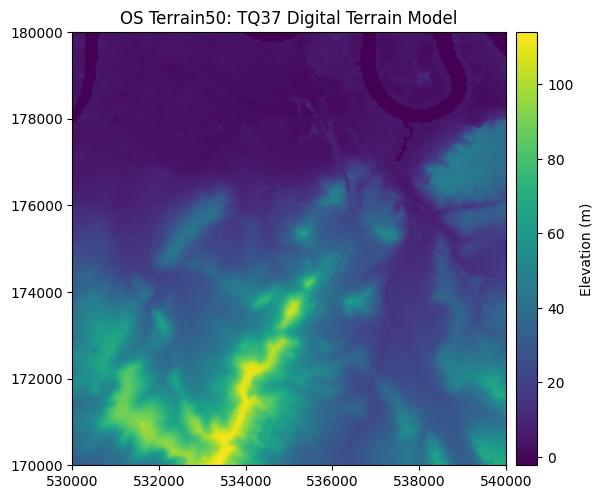

In [4]:
# Open the ASCII Grid file, display its metadata and plot
with rio.open(terrain50_tq37_path) as src:
    print(src.profile)
    print(f"CRS: {src.crs}")
    fig, ax = plt.subplots(figsize=(6, 6))
    im = show(src, transform=src.transform, ax=ax, adjust=False)
    plt.title("OS Terrain50: TQ37 Digital Terrain Model")
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1)
    cbar = plt.colorbar(im.get_images()[0], cax=cax, label="Elevation (m)")

### `rst_bounds_to_bng`
Returns a list of `BNGReference` objects representing the BNG grid squares intersected by the input raster's bounds.

In [28]:
with rio.open(terrain50_tq37_path) as dataset:
    # get BNG grid squares that intersect the raster
    squares = rst_bounds_to_bng(dataset, resolution=5000)

for s in squares:
    print(s)

BNGReference(bng_ref_formatted=TQ 3 7 SW, resolution_label=5km)
BNGReference(bng_ref_formatted=TQ 3 7 SE, resolution_label=5km)
BNGReference(bng_ref_formatted=TQ 3 7 NW, resolution_label=5km)
BNGReference(bng_ref_formatted=TQ 3 7 NE, resolution_label=5km)


`src` can be an open Rasterio dataset (e.g. to work within a context manager), or a path to a raster dataset. `resolution` can be an integer or string, but must be a valid increment within the BNG grid system.

In [34]:
for k, v in BNG_RESOLUTIONS.items():
    print(f"{k} metres (integer): {v['label']} (string)")

100000 metres (integer): 100km (string)
50000 metres (integer): 50km (string)
10000 metres (integer): 10km (string)
5000 metres (integer): 5km (string)
1000 metres (integer): 1km (string)
500 metres (integer): 500m (string)
100 metres (integer): 100m (string)
50 metres (integer): 50m (string)
10 metres (integer): 10m (string)
5 metres (integer): 5m (string)
1 metres (integer): 1m (string)


In [7]:
# get the first intersecting BNG grid square at a 5km resolution
rst_bounds_to_bng(terrain50_tq37_path, resolution="5km")[0]

BNGReference(bng_ref_formatted=TQ 3 7 SW, resolution_label=5km)

The same hierachy and traversal methods can then be used:

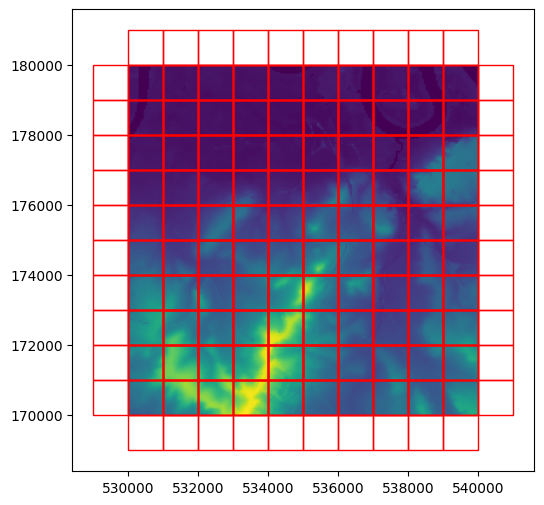

In [8]:
# find squares that neighbour raster-intersecting 1 km BNG grid squares
squares_1k = rst_bounds_to_bng(src=terrain50_tq37_path, resolution="1km")
with rio.open(terrain50_tq37_path) as dataset:
    fig, ax = plt.subplots(figsize=(6, 6))
    show(dataset, ax=ax)
    gdf = gpd.GeoDataFrame(
        geometry=[
            x.bng_to_grid_geom()
            for square in squares_1k
            for x in square.bng_neighbours()
        ]
    )
    # and plot them on top of the raster
    gdf.plot(ax=ax, facecolor="none", edgecolor="red")

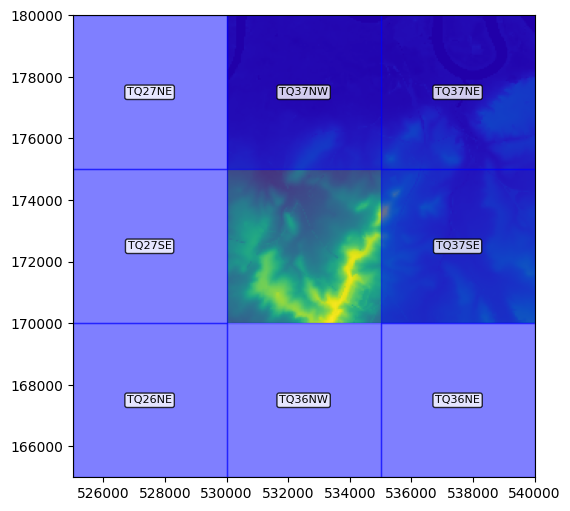

In [ ]:
# find the eight 5km squares surrounding the first 5km square intersecting the raster
squares_5k = rst_bounds_to_bng(src=terrain50_tq37_path, resolution="5km")
with rio.open(terrain50_tq37_path) as dataset:
    fig, ax = plt.subplots(figsize=(6, 6))
    plt.margins(0)  # remove margins around the plot
    show(dataset, ax=ax)
    gdf = gpd.GeoDataFrame(
        {
            "geometry": [x.bng_to_grid_geom() for x in squares_5k[0].bng_kring(1)],
            "ref": [x.bng_ref_compact for x in squares_5k[0].bng_kring(1)],
        }
    )
    gdf.plot(ax=ax, facecolor="blue", edgecolor="blue", alpha=0.5)
    for idx, row in gdf.iterrows():
        centroid = row["geometry"].centroid
        ax.text(
            centroid.x,
            centroid.y,
            row["ref"],
            ha="center",
            va="center",
            fontsize=8,
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.8),
        )

### `rst_to_bng_intersection` and the `BNGIndexedRaster` class

This function returns a `BNGIndexedRaster` object for each BNG grid square that intersects the raster. If the grid square is entirely contained by the raster, it will have an attribute `is_core = True`. If any of the grid squares extend beyond the bounds of the raster, the nodata value (or 0 if one is not specified) will be used to fill in missing data. 

The raster given to `rst_to_bng_intersection` (either as an open dataset or file path) must have square pixels with a resolution that is a factor of the BNG resolution chosen for the output objects. There must also be a height/width of at least two pixels for the BNG resolution to be considered valid (e.g. you can't index at 100 m resolution if your pixel resolution is also 100 m).

In [11]:
with rio.open(terrain50_tq37_path) as dataset:
    chips = rst_to_bng_intersection(dataset, "500m")

The `rst_read` method reads values into memory for the given chip, with the option to pass keyword arguments to Rasterio's read (e.g. if you wanted to read a specific band).

Raster data is not read into memory until it needs to be, but chip metadata is readily available for pre-processing.

In [12]:
chips[0].rst_read()

array([[[38.7, 39.5, 40.4, 41.3, 41.7, 42.4, 42.6, 43.9, 45.6, 45.3],
        [38.1, 38.6, 39.9, 40.6, 42. , 42.7, 43.3, 43.3, 44.9, 44.1],
        [37.7, 38.1, 39.4, 40.5, 41.5, 42.5, 43. , 43. , 43.2, 42.8],
        [36.9, 37.7, 38.8, 39.9, 40.9, 41.6, 42. , 41.5, 40.8, 41.2],
        [36.3, 37. , 38.1, 39.1, 40. , 40.6, 40.6, 40.1, 39.1, 38.9],
        [35.4, 36.2, 36.9, 37.7, 38.6, 39. , 39.3, 38.9, 38.1, 37.2],
        [34.4, 34.9, 35.4, 35.8, 36.7, 36.9, 37.2, 37.2, 36.4, 36.3],
        [33.3, 33.5, 33.8, 33.8, 34.7, 34.8, 35.2, 35.6, 36. , 36. ],
        [35. , 32.2, 32. , 31.9, 32.8, 33.4, 33.8, 34.1, 34.5, 34.8],
        [30.7, 34.2, 33.8, 30.7, 31.3, 31.9, 32.3, 32.7, 33.2, 33.4]]],
      dtype=float32)

Text(0.5, 1.0, 'Raster chip for BNG square TQ3070SW')

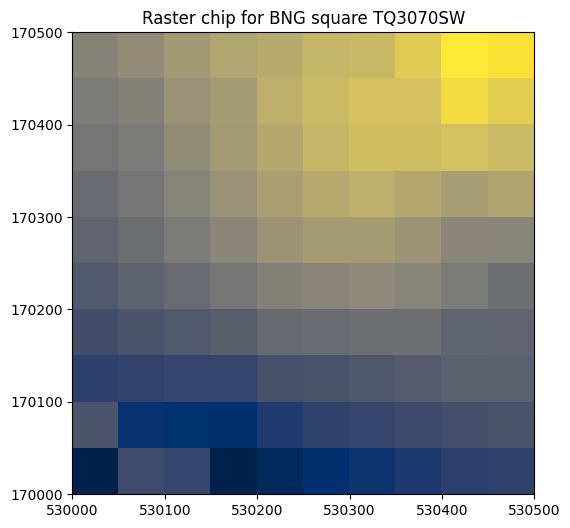

In [ ]:
fig, ax = plt.subplots(figsize=(6, 6))
# access the transform with the .transform attribute
show(chips[0].rst_read(), ax=ax, transform=chips[0].transform, cmap="cividis")
# get the BNGReference object (and then the string) from the bng_ref attribute
plt.title(f"Raster chip for BNG square {chips[0].bng_ref.bng_ref_compact}")

In [14]:
print(chips[0].profile)

{'driver': 'AAIGrid', 'dtype': 'float32', 'nodata': None, 'width': 10, 'height': 10, 'count': 1, 'crs': CRS.from_wkt('PROJCS["OSGB 1936 / British National Grid",GEOGCS["OSGB 1936",DATUM["Ordnance_Survey_of_Great_Britain_1936",SPHEROID["Airy 1830",6377563.396,299.3249646],AUTHORITY["EPSG","6277"]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",49],PARAMETER["central_meridian",-2],PARAMETER["scale_factor",0.9996012717],PARAMETER["false_easting",400000],PARAMETER["false_northing",-100000],UNIT["metre",1],AXIS["Easting",EAST],AXIS["Northing",NORTH]]'), 'transform': Affine(50.0, 0.0, np.float64(530000.0),
       0.0, -50.0, np.float64(170500.0)), 'blockxsize': 200, 'blockysize': 1, 'tiled': False}


The write method writes a chip to a given path, also with the option to provide keyword arguments for Rasterio's read. This can be helpful for intermediate saves during processing (e.g. to a temporary file).

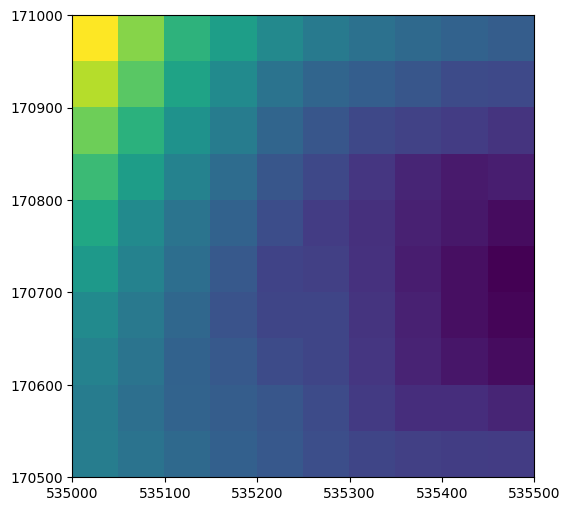

In [ ]:
# create a temporary directory to hold the output file
with tempfile.TemporaryDirectory() as tmp_dir:
    with rio.open(terrain50_tq37_path) as dataset:
        chips = rst_to_bng_intersection(dataset, 1000)
        # create an output file path based on the BNG reference of the first chip
        chip_str = chips[5].bng_ref.bng_ref_compact
        path = f"{tmp_dir}/{chip_str}.tiff"
        chips[5].rst_write(path)
    # open the written file (still within the temporary directory context) and plot it
    with rio.open(path) as src:
        result = rst_to_bng_intersection(src, 500)  # now at a finer resolution
        fig, ax = plt.subplots(figsize=(6, 6))
        im = show(result[0].rst_read(), ax=ax, transform=chips[5].transform)

### `rst_to_bng_intersection_iter` and streaming

`BNGIndexedRaster` objects can be converted to dictionary records for easy streaming and pre-processing. For example, this could allow them to be joined to vector data/spatially queried prior to reading the required data into memory.

In [16]:
chips[0].to_record()

{'bng_ref': 'TQ3070',
 'is_core': True,
 'transform': {'a': 50.0,
  'b': 0.0,
  'c': np.float64(530000.0),
  'd': 0.0,
  'e': -50.0,
  'f': np.float64(171000.0)},
 'count': 1,
 'height': 20,
 'width': 20,
 'nodata': None,
 'dtypes': {1: 'float32'},
 'filepath_in': '../data/TQ37.asc',
 'bounds_in': {'xmin': 530000.0,
  'ymin': 170000.0,
  'xmax': 540000.0,
  'ymax': 180000.0},
 'res': 50.0}

The `.from_record` class method allows chips to be recreated from records (or a minimal dictionary with the input path and bng ref):

In [17]:
BNGIndexedRaster.from_record(chips[0].to_record())

BNGIndexedRaster(src='../data/TQ37.asc', bng_ref=BNGReference(TQ3070))

In [18]:
BNGIndexedRaster.from_record(
    {
        "filepath_in": terrain50_tq37_path,
        "bng_ref": "TQ372751",
    }
)

BNGIndexedRaster(src='../data/TQ37.asc', bng_ref=BNGReference(TQ372751))

`rst_to_bng_intersection_iter` acts on a directory to find raster files and yield `BNGIndexedRaster` objects. This means multiple chips for the same tile could be returned where bounds for two rasters fall into the same BNG grid square.

An optional `filename_glob` can be used to limit to files matching a certain pattern. Chips can also be returned as dictionary records, which might be hepful in streaming contexts.

In [ ]:
raster_dir = "../data/"

chips = rst_to_bng_intersection_iter(
    raster_dir, 100, filename_glob="*.asc", as_records=True
)

pd.DataFrame(
    itertools.islice(chips, 10)
)  # put the first 10 records into a DataFrame for display

,bng_ref,is_core,transform,count,height,width,nodata,dtypes,filepath_in,bounds_in,res
0,TQ300700,True,"{'a': 50.0, 'b': 0.0, 'c': 530000.0, 'd': 0.0,...",1,2,2,None,{1: 'float32'},../data\TQ37.asc,"{'xmin': 530000.0, 'ymin': 170000.0, 'xmax': 5...",50.0
1,TQ301700,True,"{'a': 50.0, 'b': 0.0, 'c': 530100.0, 'd': 0.0,...",1,2,2,None,{1: 'float32'},../data\TQ37.asc,"{'xmin': 530000.0, 'ymin': 170000.0, 'xmax': 5...",50.0
2,TQ302700,True,"{'a': 50.0, 'b': 0.0, 'c': 530200.0, 'd': 0.0,...",1,2,2,None,{1: 'float32'},../data\TQ37.asc,"{'xmin': 530000.0, 'ymin': 170000.0, 'xmax': 5...",50.0
3,TQ303700,True,"{'a': 50.0, 'b': 0.0, 'c': 530300.0, 'd': 0.0,...",1,2,2,None,{1: 'float32'},../data\TQ37.asc,"{'xmin': 530000.0, 'ymin': 170000.0, 'xmax': 5...",50.0
4,TQ304700,True,"{'a': 50.0, 'b': 0.0, 'c': 530400.0, 'd': 0.0,...",1,2,2,None,{1: 'float32'},../data\TQ37.asc,"{'xmin': 530000.0, 'ymin': 170000.0, 'xmax': 5...",50.0
5,TQ305700,True,"{'a': 50.0, 'b': 0.0, 'c': 530500.0, 'd': 0.0,...",1,2,2,None,{1: 'float32'},../data\TQ37.asc,"{'xmin': 530000.0, 'ymin': 170000.0, 'xmax': 5...",50.0
6,TQ306700,True,"{'a': 50.0, 'b': 0.0, 'c': 530600.0, 'd': 0.0,...",1,2,2,None,{1: 'float32'},../data\TQ37.asc,"{'xmin': 530000.0, 'ymin': 170000.0, 'xmax': 5...",50.0
7,TQ307700,True,"{'a': 50.0, 'b': 0.0, 'c': 530700.0, 'd': 0.0,...",1,2,2,None,{1: 'float32'},../data\TQ37.asc,"{'xmin': 530000.0, 'ymin': 170000.0, 'xmax': 5...",50.0
8,TQ308700,True,"{'a': 50.0, 'b': 0.0, 'c': 530800.0, 'd': 0.0,...",1,2,2,None,{1: 'float32'},../data\TQ37.asc,"{'xmin': 530000.0, 'ymin': 170000.0, 'xmax': 5...",50.0
9,TQ309700,True,"{'a': 50.0, 'b': 0.0, 'c': 530900.0, 'd': 0.0,...",1,2,2,None,{1: 'float32'},../data\TQ37.asc,"{'xmin': 530000.0, 'ymin': 170000.0, 'xmax': 5...",50.0


---
A toy example using `rst_to_bng_intersection_iter` in the `__iter__` method of a class:

In [ ]:
class DummyClass:
    """A dummy class to iterate over raster chips as arrays."""

    def __init__(self, folder: str, glob: str, resolution: int):
        """Initialise with folder, glob pattern, and resolution."""
        self.folder = folder
        self.glob = glob
        self.resolution = resolution

    def __iter__(self):
        """Iterate over raster chips as arrays."""
        for chip in rst_to_bng_intersection_iter(
            self.folder, self.resolution, filename_glob=self.glob
        ):
            arr = chip.rst_read()
            yield arr

In [21]:
dataset = DummyClass(raster_dir, "*.asc", 100)

In [22]:
it = iter(dataset)
for i in range(3):
    print(next(it))

[[[35.  32.2]
  [30.7 34.2]]]
[[[32.  31.9]
  [33.8 30.7]]]
[[[32.8 33.4]
  [31.3 31.9]]]


### Understanding the effects of masks and boundless reads

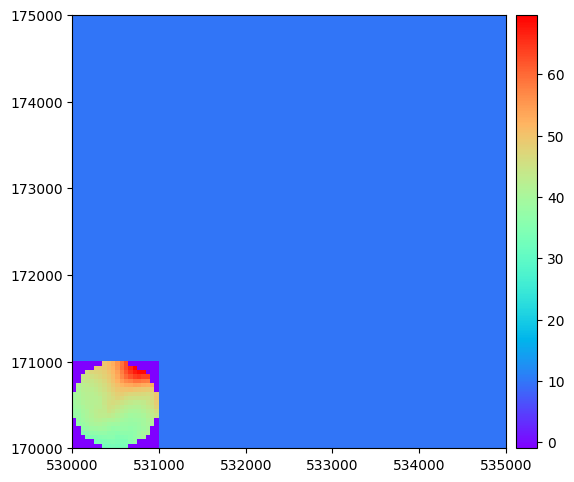

In [ ]:
squares = rst_bounds_to_bng(src=terrain50_tq37_path, resolution=1000)
with rio.open(terrain50_tq37_path) as dataset:
    # mask with a circle
    geom = [squares[0].bng_to_grid_geom().centroid.buffer(500)]
    # set no data value to -1
    # all pixels outside the masked area and within the grid square
    # will be set to this value
    out_image, out_transform = mask(dataset, geom, crop=True, nodata=-1)

    # write to a temporary file
    with tempfile.TemporaryDirectory() as tmp_dir:
        temp_path = os.path.join(tmp_dir, "masked.tif")
        profile = dataset.profile.copy()
        profile.update(
            {
                "height": out_image.shape[1],
                "width": out_image.shape[2],
                "transform": out_transform,
                "nodata": -1,
            }
        )
        with rio.open(temp_path, "w", **profile) as dst:
            dst.write(out_image)

        # chip again at a courser resolution
        chips = rst_to_bng_intersection(temp_path, 5000)
        # the rst_read method uses a boundless read
        # pixels outside the boundary of the saved raster
        # can be assigned a value different to the no data value,
        # set by the fill value
        arr = chips[0].rst_read(indexes=1, fill_value=10)
        # compare the results
        fig, ax = plt.subplots(figsize=(6, 6))
        im = show(
            arr, ax=ax, transform=chips[0].transform, adjust=False, cmap="rainbow"
        )
        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="5%", pad=0.1)
        cbar = plt.colorbar(im.get_images()[0], cax=cax)

### Combining with vector data

It is important to make use of the transform when plotting the raster data, aligning it with vector geometries using the British National Grid.

In [24]:
gdf_london = gpd.read_file("../data/Regions_December_2024_Boundaries_EN_BFC.gpkg")
gdf_london.columns = gdf_london.columns.str.lower()
# filter to only London region
gdf_london = gdf_london[gdf_london["rgn24nm"] == "London"][
    ["rgn24cd", "rgn24nm", "geometry"]
]

In [25]:
_gdf_london = gdf_london.copy()
# index at 10km resolution
_gdf_london_exp = gdf_to_bng_intersection_explode(gdf=_gdf_london, resolution="10km")
_gdf_london_exp["ref_str"] = _gdf_london_exp["bng_ref"].apply(
    lambda x: x.bng_ref_compact
)

In [26]:
# create river geometry within TQ37 by subtracting London geometry from full grid square
TQ37_geom = _gdf_london_exp[_gdf_london_exp.ref_str == "TQ37"].geometry.item()
river_geom = BNGReference("TQ37").bng_to_grid_geom().difference(TQ37_geom)

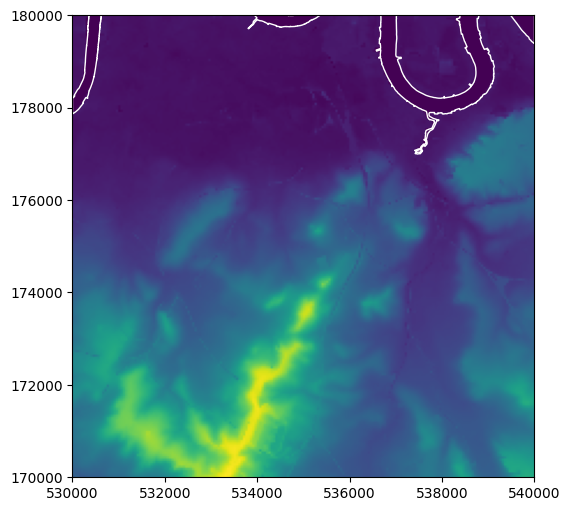

In [27]:
# using the transform, the raster can be plotted with the Thames geometry overlaid
fig, ax = plt.subplots(figsize=(6, 6))
gpd.GeoDataFrame(geometry=[river_geom]).plot(ax=ax, facecolor="none", edgecolor="white")
with rio.open(terrain50_tq37_path) as src:
    im = show(src, transform=src.transform, ax=ax, adjust=False)